# Reddit Logs to YTMusic Playlists

In [2]:
# Set Paths

# Path to header .json file for ytmusic api
ytmusic_header_path = '..'
# Path to .tsv reddit search logs
reddit_log_path = '..\\..\\reddit_scraper\\logs\\'


In [3]:
import os
import glob
import time
import math

import unicodedata
from datetime import date
import re
import pandas as pd
from IPython.display import display
from fuzzywuzzy import fuzz
from ytmusicapi import YTMusic

## Pass Fail Match Database

In [191]:

graded_matches =[
    'reddit_ytmusic_scored_matches_and_graded_2021-10-16_fixed_11-6.tsv',
    'reddit_scraped-2019_ytmusic_scored_matches_and_partly_graded_2021-10-23.tsv',
    'reddit_scraped-2019_and_2021-refresh_ytmusic_scored_and_graded_matches_2021-10-24.tsv',
    'reddit_scraped-2019_ytmusic_scored_album_matches_and_graded_2021-11-01.tsv',
    'reddit_scraped-2019_and_2021-refresh_ytmusic_scored_and_graded_matches_2021-11-5.tsv',
]
failed_queries = [
    'reddit_ytmusic_failed_matches_2021-10-16.tsv', 
    'reddit_scraped-2019_ytmusic_failed_matches_2021-10-24.tsv',
    'reddit_scraped-2019_ytmusic_failed_album_matches_2021-10-24.tsv',
    'reddit_2021-refresh_ytmusic_failed_matches_2021-10-24.tsv',
    'reddit_scraped-2019_ytmusic_failed_album_matches_2021-11-01.tsv'
    ]
all_failed = []
all_pass_match = []
all_fail_match = []

for f in graded_matches:
    tsv = os.path.join(reddit_log_path, 'ytmusic\\old', f)
    df = pd.read_csv(tsv, sep='\t')
    all_pass_match.append(df.loc[df.manual_check == 'ok'])
    all_fail_match.append(df.loc[df.manual_check == 'x'])
for f in failed_queries:
    tsv = os.path.join(reddit_log_path, 'ytmusic\\old', f)
    df = pd.read_csv(tsv, sep='\t', index_col=0)
    all_failed.append(df)


print('Saving graded passing matches to reddit queries')
all_pass_match = pd.concat(all_pass_match).reset_index(drop=True)
all_pass_match['reddit_sub_id'] = all_pass_match.reddit_sub + '/' + all_pass_match.reddit_key
l = len(all_pass_match)
all_pass_match = all_pass_match.drop_duplicates('reddit_sub_id').sort_values('reddit_sub')
print(f' dropped {l - len(all_pass_match)} duplicates')
all_pass_match_file = os.path.join(
    reddit_log_path, 'ytmusic', f'reddit_ytmusic_graded_matches_pass_{date.today()}.tsv')
all_pass_match.to_csv(all_pass_match_file, sep='\t', header=True)
print(f'Saved {len(all_pass_match)} graded pass matched tracks')

print('Saving graded failed matches to reddit queries')
all_fail_match = pd.concat(all_fail_match).reset_index(drop=True)
all_fail_match['reddit_sub_id'] = all_fail_match.reddit_sub + '/' + all_fail_match.reddit_key
l = len(all_fail_match)
all_fail_match = all_fail_match.drop_duplicates('reddit_sub_id').sort_values('reddit_sub')
print(f' dropped {l - len(all_fail_match)} duplicates')
all_fail_match_file = os.path.join(
    reddit_log_path, 'ytmusic', f'reddit_ytmusic_graded_matches_fail_{date.today()}.tsv')
all_fail_match.to_csv(all_fail_match_file, sep='\t', header=True)
print(f'Saved {len(all_fail_match)} graded fail matched tracks')

print('Saving failed to match reddit queries')
all_failed = pd.concat(all_failed)
all_failed['reddit_sub_id'] =  all_failed.reddit_sub + '/' +  all_failed.reddit_key
l0 = len(all_failed)
all_failed = all_failed.drop_duplicates('reddit_sub_id').sort_values('reddit_sub')
print(f' dropped {l0 - len(all_failed)} duplicate failed tracks')
all_failed_file = os.path.join(
    reddit_log_path, 'ytmusic', f'reddit_ytmusic_match_failed_{date.today()}.tsv')
all_failed.to_csv(all_failed_file, sep='\t', header=True)
print(f'Saved {len(all_failed)} failed tracks')

Saving graded passing matches to reddit queries
 dropped 2372 duplicates
Saved 23777 graded pass matched tracks
Saving graded failed matches to reddit queries
 dropped 815 duplicates
Saved 9830 graded fail matched tracks
Saving failed to match reddit queries
 dropped 121 duplicate failed tracks
Saved 1532 failed tracks


## Show score distributions

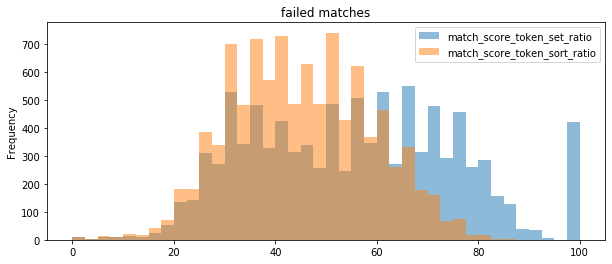

In [192]:
SCORE_COLS = ['match_score_token_set_ratio', 'match_score_token_sort_ratio']
all_fail_match[SCORE_COLS].plot.hist(title='failed matches', bins=40, alpha=0.5, figsize=(10,4))

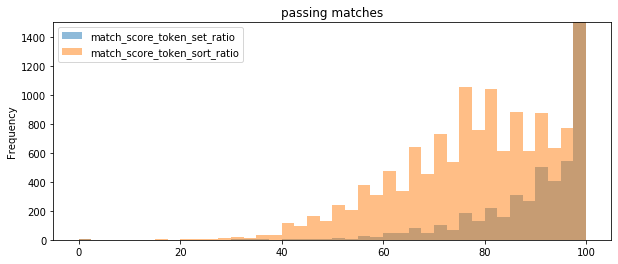

In [193]:
all_pass_match[SCORE_COLS].plot.hist(title='passing matches', bins=40, alpha=0.5, figsize=(10,4), ylim=(0,1500))

## YTMusic API and Functions

In [36]:
def parse_ytmusic_tracks(track_list):
    tracks = pd.DataFrame(track_list)
    tracks['artistId'] = tracks['artists'].dropna().apply(
        lambda x: x[0]['id'])  # TODO handle > 1 artist
    tracks['artist'] = tracks['artists'].dropna().apply(lambda x: x[0]['name'])
    tracks['albumId'] = tracks['album'].dropna().apply(lambda x: x['id'])
    tracks['album'] = tracks['album'].dropna().apply(lambda x: x['name'])
    tracks = tracks.drop('thumbnails', axis=1)
    tracks = tracks.drop('artists', axis=1)
    return tracks

def parse_ytmusic_playlist(yt, playlist_meta):
    playlist_meta.pop('thumbnails', None)
    track_list = playlist_meta.pop('tracks', None)
    tracks = parse_ytmusic_tracks(track_list)
    return tracks, playlist_meta
    
ytm = YTMusic(os.path.join(ytmusic_header_path, 'headers_auth.json'))
yt_res_cache = {}
yt_unmatched_cache = {}

## String Helper Functions

In [181]:
def scrub_title(title):
    title = title.lower().strip()
    title = unicodedata.normalize('NFKD', title).encode(
        'ascii', 'ignore').decode()
    
    # check for album
    is_album = False
    for k in ['full album', '(album)', 'album stream']:
        if k in title:
            is_album = True

    title = title.replace('ft.', 'feat.')
    # remove stuff at end of title
    for k in [
         'official video', 'music video', 'live video','lyric video', 
         'album stream', 'album review', 'album version', 'produced by']:
        if k in title:
            title = title.split(k)[0]
    start_char = ['[', '('] 
    for k in [
        'official', 'unoffical', 'free', 'explicit', 'video', 'music', 'nsfw', 'live', 'original', 'lyric',
        'full', 'album)', 'audio)', 'cover)', 'convert', 'thissongissick', 'duploc', 'prod', 'prod.', 'produced by', 'leak', 'from', 'lofi hip', 
        'remaster', 'uncensored', '720p', '1080p', '320k' 'repackag', '19', '20', 'dir']:
        for s in start_char:
            k = s + k
            if k in title:
                title = title.split(k)[0]
    for s in start_char:
        if title.endswith(s):
            title = title[:-1]     
    # remove tokens from title
    for k in ['[hd]', '[hq]', 'hd', 'hq']:
        if k in title:
            title=title.replace(k, '')
    return title, is_album

def strip_non_alphanumeric(value):
    value = str(re.sub('[^\\w\\s-]', ' ', str(value)))
    value = str(re.sub('[-\\s]+', ' ', str(value)))
    return value.strip()    

def extract_match_scores(query, match):
    q = strip_non_alphanumeric(query).lower()
    m = strip_non_alphanumeric(match).lower()
    return {
        'token_set_ratio': fuzz.token_set_ratio(q, m),
        # 'ratio': fuzz.ratio(q, m),
        'token_sort_ratio': fuzz.token_sort_ratio(q, m),
    }

## Parse Reddit .tsv and query YTMusic for Match

* Now checks db tsv to see if ialready matched (basd on sub and url)
* Some reddit entries are albums, most are tracks
* lots of title 'scrubbing' before query to clean
* saves match and unmatched seperatly, caches query responses 
    * cache in above ytmusic api cell
* scores match using fuzz metrics
    * tries to automate passing macthes with score threshold


#### Last run 11/5/2021


In [194]:
db_tsv_files ={
    'passed-match': 'reddit_ytmusic_graded_matches_pass_2021-11-06.tsv',
    'failed-match': 'reddit_ytmusic_graded_matches_fail_2021-11-06.tsv', 
    'no-match': 'reddit_ytmusic_match_failed_2021-11-06.tsv'
}
# load dbs
dbs = {}
for name, f in db_tsv_files.items():
    tsv_path = os.path.join(reddit_log_path, 'ytmusic\\old', f)
    dbs[name] = pd.read_csv(tsv_path, sep='\t', index_col=0)

# remove scraped file queries from db
for name, df in dbs.items():
    print(name)
    df = df.loc[df.reddit_file.isnull()]
    print(f'{len(dbs[name]) - len(df)} of {len(dbs[name])} entries removed null reddit title')
    df = df.dropna(axis=1, how='all')
    print(f'{set(dbs[name].columns) - set(df.columns)} columns removed')
    df['reddit_post_id'] = df.reddit_sub + '//' + df.reddit_source_url
    df['manual_label'] = name
    dbs[name] = df

db = pd.concat(list(dbs.values()))
# del dbs

passed-match
12633 of 23777 entries removed null reddit title
{'reddit_file'} columns removed
failed-match
4128 of 9830 entries removed null reddit title
{'reddit_file'} columns removed
no-match
442 of 1532 entries removed null reddit title
{'reddit_file', 'reddit_filename'} columns removed


In [201]:
reddit_subfolders = ['2021_refresh', '2019']

log_tsvs = []
for folder in reddit_subfolders:
    tsv_path = os.path.join(reddit_log_path, folder)
    log_tsvs += list(glob.glob(os.path.join(tsv_path, '*.tsv')))
log_tsvs = sorted(log_tsvs)
print(f'Found {len(log_tsvs)} reddit tsvs')

log_every_n_matches = 1000
tail_n_entries = 10
fname_splitter = '_'
expected_fname_toks = 4
expected_cols = ['reddit', 'youtube_id', 'title', 'url', 'author', 'timestamp',
                 'description', 'likes', 'dislikes', 'num_comments', 'num_plays',
                 'is_media', 'thumb_url', 'num_views']

matched_entries = []
unmatched_entries = []
for i, tsv_file in enumerate(log_tsvs):
    name = os.path.splitext(os.path.basename(tsv_file))[0]
    toks = name.split(fname_splitter)
    if len(toks) != expected_fname_toks:
        print(
            f'skipping tsv without {expected_fname_toks} "{fname_splitter}" split toks: {tsv_file}')
        continue
    sub, agg, count, timestamp = toks
    df = pd.read_csv(tsv_file, sep='\t', index_col=0)
    if len(df) == 0:
        print(f'\n\nSkipping empty tsv: {tsv_file}')
        continue
    print(f'\n\n({i}/{len(log_tsvs)})  Loaded {len(df)} entries with {len(df.columns)} columns from {name}')
    assert set(df.columns) == set(expected_cols)

    # Loop thru entries
    for entry in df.itertuples():
        if 'youtube' not in entry.url and 'soundcloud' not in entry.url:
            print(f' skipping, Unknown url source {entry.url}')
        title_key, is_album = scrub_title(entry.title)
        
        # If already in db get match from there
        post_id = sub + '//' + entry.url
        if post_id in db.reddit_post_id:
            continue

        # Check cache for saved YTMusic query response or previous match failures        
        if entry.url in yt_res_cache:
            match = yt_res_cache[entry.url]
            if 'ytmusic_artists' in match:
                print(f'fixing artist for album: {entry.title}')
                match['ytmusic_artist'] = match.pop('ytmusic_artists')
            if 'ytmusic_playlist_id' in match:
                match.pop('ytmusic_playlist_id')
        elif title_key in yt_unmatched_cache:
            # print(f'Skipping: previously unmatched entry: {title_key}')
            unmatch = yt_unmatched_cache[title_key]
            unmatch['reddit_post_id'] = post_id
            unmatch['manual_label'] = 'no-match'
            unmatched_entries.append(unmatch)
            continue
        # Query YTMusic
        else:
            match = {}
            try:
                if is_album:
                    res = ytm.search(query=title_key, filter='albums', limit=1)
                    if len(res):
                        res = res[0]
                        match['is_album'] = True
                        match['ytmusic_title'] = ''
                        match['ytmusic_album'] = res.get('title', '')
                        match['ytmusic_albumId'] = res.get('browseId', '')
                        if 'artists' in res:
                            match['ytmusic_artist'] = res['artists'][0].get('name', '')
                            match['ytmusic_artistId'] = res['artists'][0].get('id', '')
                        match['ytmusic_key'] = f"{match.get('ytmusic_artist', '')} - {match.get('ytmusic_album', '')}".lower()

                else:
                    res = ytm.search(query=title_key, filter='songs', limit=1)
                    if len(res):
                        res = res[0]
                        match['is_album'] = False
                        match['ytmusic_album'] = ''
                        if 'album' in res:
                            match['ytmusic_album'] = res['album'].get('name', '')
                            match['ytmusic_albumId'] = res['album'].get('id', '')
                        if 'artists' in res:
                            match['ytmusic_artist'] = res['artists'][0].get('name', '')
                            match['ytmusic_artistId'] = res['artists'][0].get('id', '')
                        match['ytmusic_title'] = res.get('title', '')
                        match['ytmusic_videoId'] = res.get('videoId', '')
                        match['ytmusic_key'] = f"{match.get('ytmusic_artist', '')} - {match.get('ytmusic_title', '')}".lower()

            except Exception as e:
                print(f'Error with {entry.title}: {e}')
                pass

            # Store unmatched ytmusic query
            if len(res) == 0:
                unmatch = {}
                unmatch['reddit_title'] = entry.title
                unmatch['reddit_source_url'] = entry.url
                unmatch['reddit_key'] = title_key
                unmatch['reddit_sub'] = sub
                unmatch['reddit_post_id'] = post_id
                unmatch['reddit_sub_id'] = f'{sub}-{title_key}'
                unmatch['reddit_aggregator'] = agg
                unmatch['manual_label'] = 'no-match'
                unmatched_entries.append(unmatch)
                yt_unmatched_cache[title_key] = unmatch
                print(f'Skipping : {entry.title}')
                continue


            # Other ytmusic fields
            match['ytmusic_entry'] = f"{match.get('ytmusic_artist', '')} - {match.get('ytmusic_title', '')} - {match.get('ytmusic_album', '')}"
            match['ytmusic_duration'] = res['duration']
            match['ytmusic_year'] = res['year']
            match['ytmusic_resultType'] = res['resultType']
            yt_res_cache[entry.url] = match

        # Reddit fields
        match['reddit_title'] = entry.title
        match['reddit_key'] = title_key
        match['reddit_sub'] = sub
        match['reddit_post_id'] = post_id
        match['reddit_sub_id'] = f'{sub}-{title_key}'
        match['reddit_aggregator'] = agg
        match['reddit_source_url'] = entry.url
        match['youtube_videoId'] = entry.youtube_id
        match['manual_label'] = f'no-label_{date.today()}'

        # Match Score
        try:
            scores = extract_match_scores(
                match['reddit_key'], match['ytmusic_key'])
            for sk, sv in scores.items():
                match[f'match_score_{sk}'] = sv
            # Using manual grading to set thresholds
            if scores['token_sort_ratio'] < 40 or scores['token_set_ratio'] < 60:
                match['match_quality'] = 0.
            elif scores['token_sort_ratio'] > 75 or scores['token_set_ratio'] > 75:
                match['match_quality'] = 1.
            else:
                match['match_quality'] = 0.5
        except Exception as e:
            match['match_quality'] = 0.0
            print(f'Skipping match score for {entry.title}.\n  Match Error: {e}')


        # Update match results
        matched_entries.append(match)

# Process Matched entries
match_df = pd.DataFrame(matched_entries)
orig_len = len(match_df)
match_df = match_df.drop_duplicates(subset='reddit_sub_id', keep='first')
print(f'Dropped {orig_len - len(match_df)} subreddit match duplicates')
print(f'\n\nSaving output tsvs to {reddit_log_path}')
match_file = os.path.join(reddit_log_path, 'ytmusic',
                          f'reddit_2019-and-2021-refresh_ytmusic_scored_new_matches_{date.today()}.tsv')
match_df.to_csv(match_file, sep='\t', header=True)

# Process Unmatched entries
unmatch_df = pd.DataFrame(unmatched_entries)
orig_len = len(unmatch_df)
unmatch_df = unmatch_df.drop_duplicates(subset='reddit_sub_id', keep='first')
print(f'Dropped {orig_len - len(unmatch_df)} subreddit unmatch duplicates')
unmatch_file = os.path.join(
    reddit_log_path, 'ytmusic', f'reddit_2019-and-2021-refresh_ytmusic_failed_new_matches_{date.today()}.tsv')
unmatch_df.to_csv(unmatch_file, sep='\t', header=True)


Found 89 reddit tsvs


(0/89)  Loaded 503 entries with 14 columns from 90shiphop_top-all_1000_1564979404


(1/89)  Loaded 386 entries with 14 columns from blues_top-all_1000_1564979329


(2/89)  Loaded 644 entries with 14 columns from chillmusic_top-all_1000_1564979303


(3/89)  Loaded 479 entries with 14 columns from chillmusic_top-year_1000_1565060512


(4/89)  Loaded 592 entries with 14 columns from chillwave_top-all_1000_1564979428


(5/89)  Loaded 455 entries with 14 columns from chillwave_top-year_1000_1565060539


(6/89)  Loaded 682 entries with 14 columns from futurebass_top-all_1000_1564979440


(7/89)  Loaded 540 entries with 14 columns from futurebass_top-year_1000_1565060550
Skipping match score for ethereal by dystxpia.
  Match Error: 'ytmusic_key'


(8/89)  Loaded 6 entries with 14 columns from futurebeats_hot-month_10_1565082049


(9/89)  Loaded 6 entries with 14 columns from futurebeats_hot-month_10_1565082099


(10/89)  Loaded 24 entries with 14 columns from futurebeat

## merge new macthes with db

In [226]:
unmatch_df = pd.read_csv(unmatch_file, sep='\t', index_col=0)
unmatch_db = dbs['no-match']
unmatch_all = pd.concat([unmatch_db, unmatch_df])
print(f'Merged unmatched to {len(unmatch_all)} entries')
unmatch_all = unmatch_all.drop_duplicates('reddit_post_id')
unmatch_all = unmatch_all.drop(['reddit_post_id', 'reddit_sub_id'], axis=1)
print(f'Removed duplicates now {len(unmatch_all)} entries')
for grp, df in unmatch_all.groupby('manual_label'):
    print(f'  {len(df)} unmatched with {grp}')

match_df = pd.read_csv(match_file, sep='\t', index_col=0)
match_db = pd.concat([dbs['passed-match'], dbs['failed-match']])
match_db = match_db.drop(['idx b', 'idx a'], axis=1)
match_df['manual_check'] = ''
match_all = pd.concat([match_db, match_df])
print(f'Merged matched to {len(match_all)} entries')
match_all = match_all.drop_duplicates('reddit_post_id')
match_all = match_all.drop(['reddit_post_id', 'reddit_sub_id'], axis=1)
print(f'Removed duplicates now {len(match_all)} entries')
for grp, df in match_all.groupby('manual_label'):
    print(f'  {len(df)} matches with {grp}')

db_all = pd.concat([match_all, unmatch_all]).sort_values('reddit_sub').reset_index(drop=True)
print(f'Entries db has {len(db_all)} matched and unmatched entries')


Merged unmatched to 2192 entries
Removed duplicates now 1218 entries
  1218 unmatched with no-match
Merged matched to 35133 entries
Removed duplicates now 18519 entries
  5701 matches with failed-match
  1674 matches with no-label_2021-11-06
  11144 matches with passed-match
Entries db has 19737 matched and unmatched entries


### fix auto grade based on latest rule

In [242]:
match_quality = []
for i, row in db_all.iterrows():
    if row['match_quality'] >= 0:
        match_quality.append(row.match_quality)
    elif row['match_score_token_sort_ratio'] < 40 or row['match_score_token_set_ratio'] < 60:
        match_quality.append(0.)
    elif row['match_score_token_sort_ratio'] > 75 or row['match_score_token_set_ratio'] > 75:
        match_quality.append(1.)
    elif row['match_score_token_sort_ratio'] >= 0 and row['match_score_token_set_ratio'] >= 0:
        match_quality.append(0.5)
    else:
        match_quality.append(row['match_quality'])
    
assert len(match_quality) == len(db_all)
db_all['match_quality'] = match_quality


## Save Db tsv

In [243]:
db_all_file = os.path.join(
    reddit_log_path, 'ytmusic', f'reddit_ytmusic_subreddit_db.tsv')
db_all.to_csv(db_all_file, sep='\t', header=True)

## Save tsv for manual grading

In [10]:
# db_all_file = os.path.join(
#     reddit_log_path, 'ytmusic', f'reddit_ytmusic_subreddit_db.tsv')
# db_all = pd.read_csv(db_all_file, sep='\t', index_col=0)
for grp, df in db_all.groupby('manual_label'):
    print(f'{len(df)} matches with {grp}')

need_label = db_all.loc[db_all.manual_label.str.contains('no-label') ]
need_label_file = os.path.join(
    reddit_log_path, 'ytmusic', f'reddit_ytmusic_subreddit_db_need_manual_label.tsv')
need_label.to_csv(need_label_file, sep='\t', header=True)
print(f'Saved {len(need_label)} that need manual labeling to {need_label_file}')

5701 matches with failed-match
1674 matches with no-label_2021-11-06
1218 matches with no-match
11144 matches with passed-match
Saved 1674 that need manual labeling to ..\..\reddit_scraper\logs\ytmusic\reddit_ytmusic_subreddit_db_need_manual_label.tsv
